<a href="https://colab.research.google.com/github/mdreduanulhoque/AI_ML_Expert_with_Phitron/blob/main/Machine_Learning/ML_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ML FINAL EXAM

### Email: mdreduanulhoquesadik@gmail.com

Task: Copy this notebook on your drive and answer in that copy

Choose a dataset of your choice from kaggle or UCI

Some suggestions:https://www.kaggle.com/datasets/ahmettezcantekin/beginner-datasets

You may choose a dataset of your choice too

In this exam:
1. Provide code and explaination(in text cell) whenever needed and you must show the outputs
2. Before submitting run all cells and make sure the outputs are visible


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder


## 0. Dataset overview

Why you choose this dataset and what did you observe from the dataset description



  

https://www.kaggle.com/datasets/sadmansakib7/ecg-arrhythmia-classification-dataset

## Answer:
Two-three weeks ago, one of my faculty told me to create a model on this dataset, just for learning purpose.
The dataset describes the ECG machine's electrical signals of LEAD II and LEAD V5 in numerical ways, rather than row electrical data. It comes with the duration of our heart pump, peaks, time duration between different position of our heart and so on.

# 1. Dataset description (15 marks)


### Dataset Description
1. How many features?
2. Classification or regression problem? Why do you think so?
3. How many data points?
4. Is there any null values?
5. What kind of features are in your dataset? (Quantitative / Categorical)
6. Do you need to encode the categorical variables, why or why not?
7. Correlation of all the features, What do you understand after the correlation test?
8. Perform exploratory data analysis to extract some important relationships from your data.


Provide necessary codes and explanation

In [51]:
df = pd.read_csv("/content/MIT-BIH Arrhythmia Database.csv")

In [52]:
df.columns

Index(['record', 'type', '0_pre-RR', '0_post-RR', '0_pPeak', '0_tPeak',
       '0_rPeak', '0_sPeak', '0_qPeak', '0_qrs_interval', '0_pq_interval',
       '0_qt_interval', '0_st_interval', '0_qrs_morph0', '0_qrs_morph1',
       '0_qrs_morph2', '0_qrs_morph3', '0_qrs_morph4', '1_pre-RR', '1_post-RR',
       '1_pPeak', '1_tPeak', '1_rPeak', '1_sPeak', '1_qPeak', '1_qrs_interval',
       '1_pq_interval', '1_qt_interval', '1_st_interval', '1_qrs_morph0',
       '1_qrs_morph1', '1_qrs_morph2', '1_qrs_morph3', '1_qrs_morph4'],
      dtype='object')

In [53]:
df.shape

(100689, 34)

In [54]:
df.isnull().sum().sum()

np.int64(0)

In [55]:
df.dtypes

,0
record,int64
type,object
0_pre-RR,int64
0_post-RR,float64
0_pPeak,float64
0_tPeak,float64
0_rPeak,float64
0_sPeak,float64
0_qPeak,float64
0_qrs_interval,int64


<Axes: >

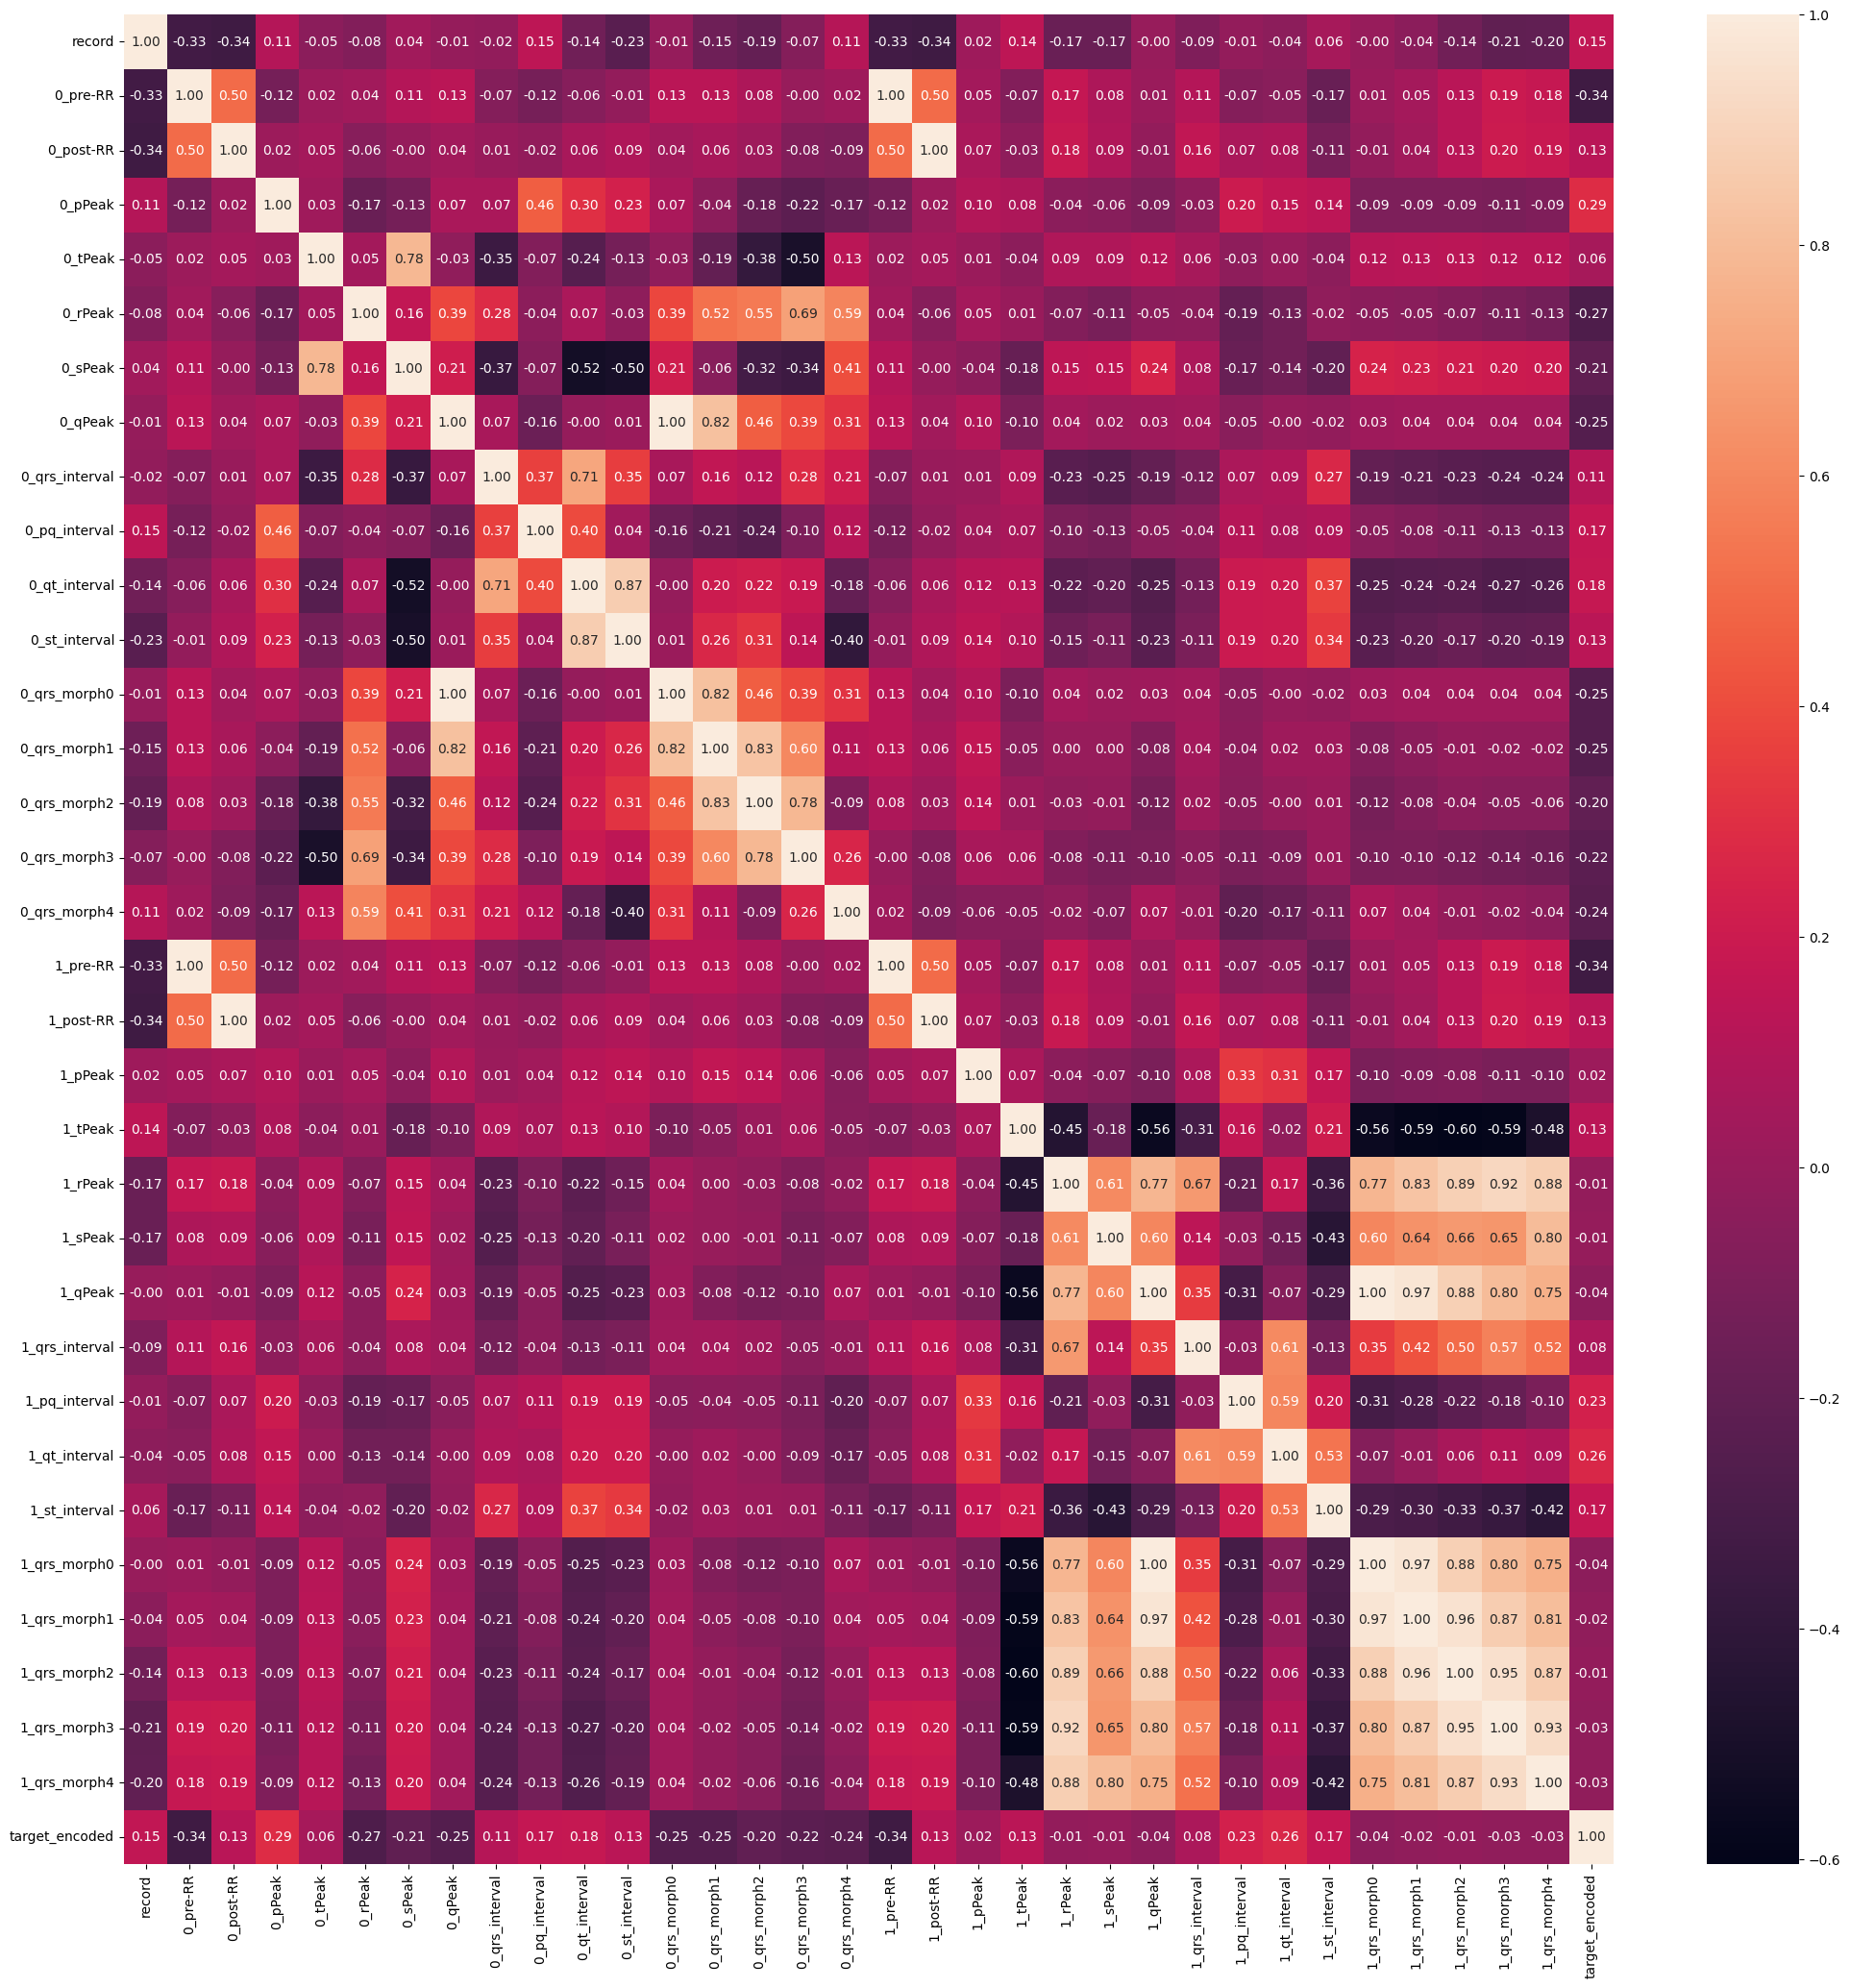

In [56]:
le = LabelEncoder()
df['target_encoded'] = le.fit_transform(df['type'])

features = df.drop('type', axis=1)
matrix = features.corr()

plt.figure(figsize=(25, 25))
sns.heatmap(matrix, annot=True, fmt=".2f")



EDA

<Axes: >

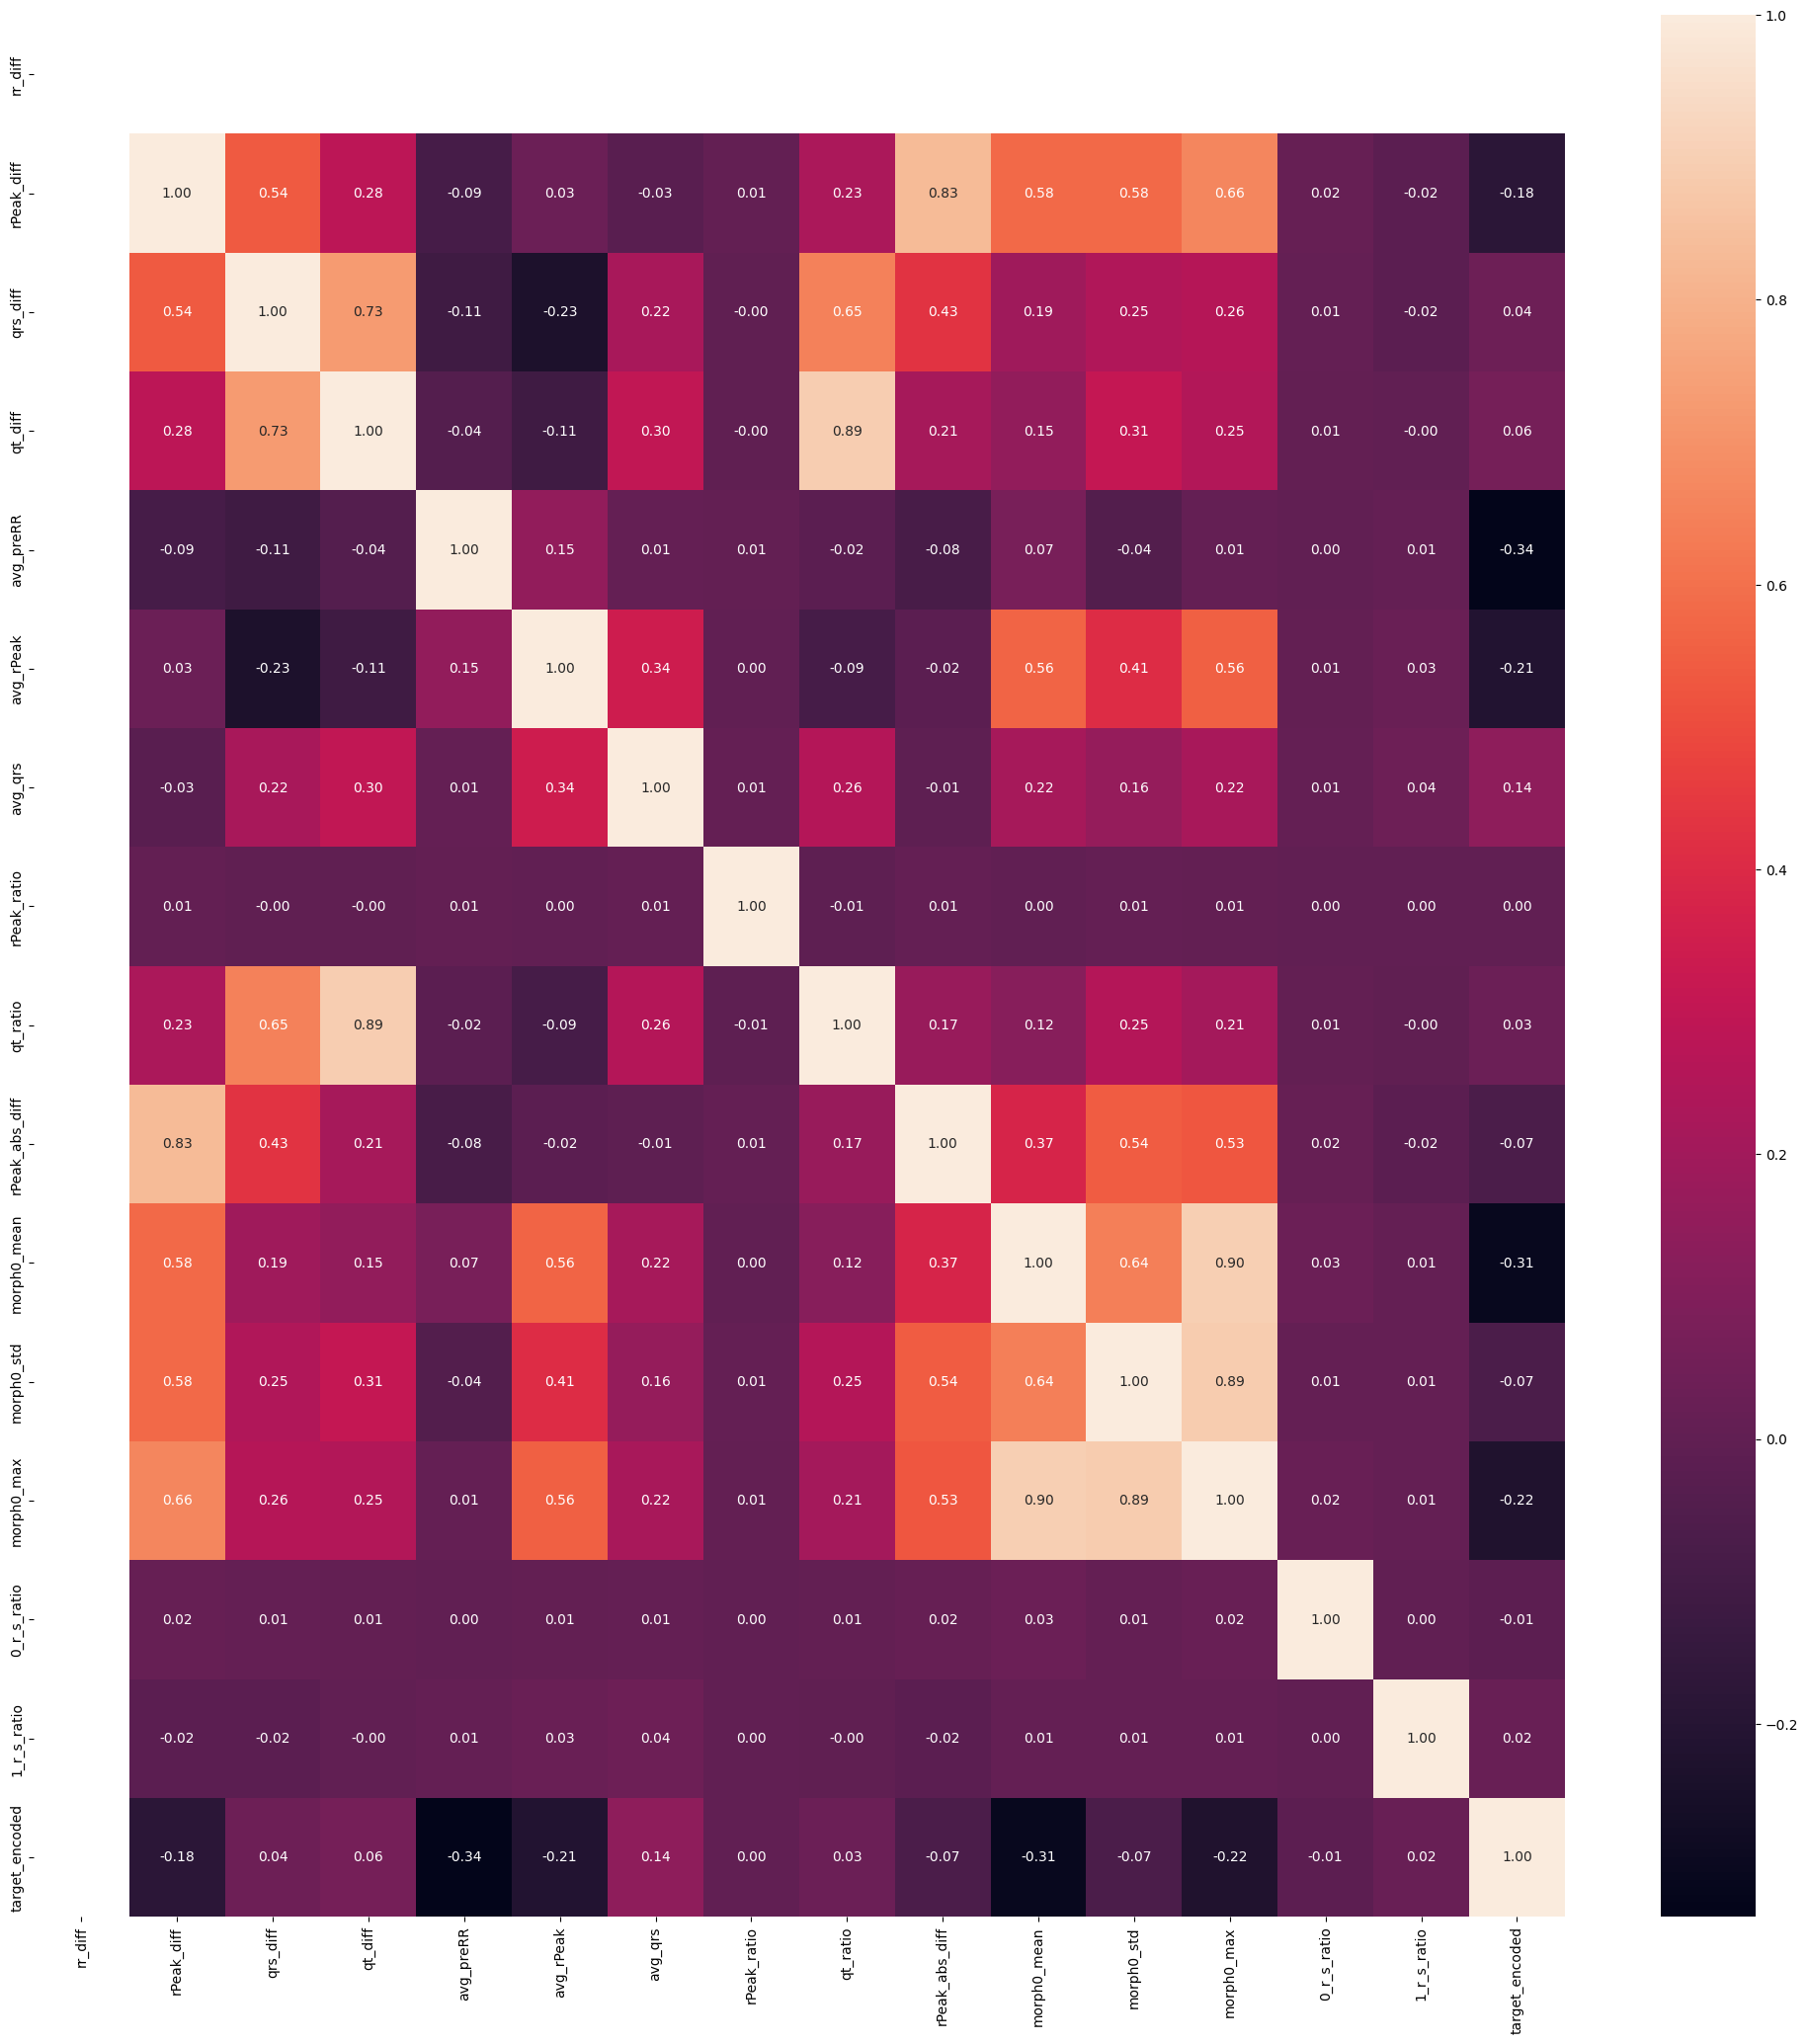

In [63]:
df['rr_diff'] = df['0_pre-RR'] - df['1_pre-RR']
df['rPeak_diff'] = df['0_rPeak'] - df['1_rPeak']
df['qrs_diff'] = df['0_qrs_interval'] - df['1_qrs_interval']
df['qt_diff'] = df['0_qt_interval'] - df['1_qt_interval']

df['avg_preRR'] = (df['0_pre-RR'] + df['1_pre-RR']) / 2
df['avg_rPeak'] = (df['0_rPeak'] + df['1_rPeak']) / 2
df['avg_qrs'] = (df['0_qrs_interval'] + df['1_qrs_interval']) / 2

df['rPeak_ratio'] = df['0_rPeak'] / (df['1_rPeak'] + 1e-6)
df['qt_ratio'] = df['0_qt_interval'] / (df['1_qt_interval'] + 1e-6)

df['rPeak_abs_diff'] = abs(df['0_rPeak'] - df['1_rPeak'])

morph_cols = ['0_qrs_morph0','0_qrs_morph1','0_qrs_morph2','0_qrs_morph3','0_qrs_morph4']
df['morph0_mean'] = df[morph_cols].mean(axis=1)
df['morph0_std'] = df[morph_cols].std(axis=1)
df['morph0_max'] = df[morph_cols].max(axis=1)

df['0_r_s_ratio'] = df['0_rPeak'] / (abs(df['0_sPeak']) + 1e-6)
df['1_r_s_ratio'] = df['1_rPeak'] / (abs(df['1_sPeak']) + 1e-6)

eda_df = df[['rr_diff', 'rPeak_diff', 'qrs_diff', 'qt_diff', 'avg_preRR', 'avg_rPeak', 'avg_qrs', 'rPeak_ratio', 'qt_ratio', 'rPeak_abs_diff', 'morph0_mean', 'morph0_std', 'morph0_max', '0_r_s_ratio', '1_r_s_ratio', 'target_encoded']].copy()

matrix = eda_df.corr()

plt.figure(figsize=(25, 25))
sns.heatmap(matrix, annot=True, fmt=".2f")

Start from implementing random forest

##Answer:





1. Features: ['record', '0_pre-RR', '0_post-RR', '0_pPeak', '0_tPeak',
       '0_rPeak', '0_sPeak', '0_qPeak', '0_qrs_interval', '0_pq_interval',
       '0_qt_interval', '0_st_interval', '0_qrs_morph0', '0_qrs_morph1',
       '0_qrs_morph2', '0_qrs_morph3', '0_qrs_morph4', '1_pre-RR', '1_post-RR',
       '1_pPeak', '1_tPeak', '1_rPeak', '1_sPeak', '1_qPeak', '1_qrs_interval',
       '1_pq_interval', '1_qt_interval', '1_st_interval', '1_qrs_morph0',
       '1_qrs_morph1', '1_qrs_morph2', '1_qrs_morph3', '1_qrs_morph4']
       total: 33
  Target: ['type']

2. Classification problem, as I will try to predict the type of Arryhythmia    based on features.

3. Total datapoints: 100689

4. No null values !!

5. All features are quantitative, some are int64 and others are float64. But our target column is object.

6. I don't have any catagorical feature in my dataset. But I need to do Label Encoding for feature column.

7. There is no single feaure that impacts most, all features plays a role in predicting the target column. However, if we combine two or three same type columns together, we may find some heavey relationship.



#2. Dataset pre-processing (15 marks)

1. Provide code
2. Discuss the pre processing steps you applied and why?


## Answer:


   

#3.Feature selection and Dataset splitting (10 marks)

1. Which features you wanna keep ? Justify and drop and rest or apply any other feature engineering step
2. Perform Train test split

## Answer:



#4.  Pipeline Creation (Supervised) (10 marks)

Select 2 models of your choice and build 2 pipelines for them

## Answer:

# 5. Model Training (5 marks)

Train those 2 models



## Answer:

#6. Model selection/Comparison analysis (15 marks)
* Bar chart showcasing prediction accuracy of all models (for classification)
* Precision, recall comparison of each model. (for classification)
* Confusion Matrix (for classification)
* R2 score and Loss  (for regression)

Compare the results of all models based on all of the above described metrics. Why do you think this model performed better than the other one for this dataset?

# Answer:

# 7. Treating the problem as Unsupervised (20 marks) ( Explore the topic as you wish )

1. Treat the problem as a unsupervised problem and perform any unsupervised model and evalute the result
2. Which method worked better? supervised or unsupervised approach and why?

# Answer:

#8. Self Reflection on this machine learning course (10 marks)

Explain the hardest and the easiest topic of this course according to you in a intuitive way (you may also provide real world implementation , necessity etc along with the explaination)

##Answer: